# Hauptkomponentenanalyse (PCA): Dimensionsreduktion von Grund auf

**Notebook 07 der Reihe *Algorithmen des Maschinellen Lernens***

Autor: Mark Baumann · Sprache: Deutsch · Kernel: Python 3

---

## Zusammenfassung

Notebook 03 zeigte, wie irrelevante Zusatzdimensionen die Leistung von k-NN
verschlechtern (Fluch der Dimensionalität). Die Hauptkomponentenanalyse (PCA) ist das
klassische Werkzeug, um hochdimensionale Daten verlustarm auf wenige, informative
Richtungen zu reduzieren. Dieses Notebook leitet PCA über zwei äquivalente
Formulierungen her — Varianzmaximierung und Rekonstruktionsfehler-Minimierung —, zeigt
den Zusammenhang zur Eigen- und Singulärwertzerlegung aus Notebook 00, implementiert
PCA vollständig mit `NumPy`, wendet sie auf den handschriftlichen Ziffern-Datensatz
(`sklearn.datasets.load_digits`) an, demonstriert den Kompromiss zwischen
Rekonstruktionsqualität und Kompressionsgrad, und zeigt abschließend empirisch, wie
PCA den in Notebook 03 beobachteten Leistungsverlust von k-NN durch irrelevante
Dimensionen mildert.

## Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. PCA sowohl als Varianzmaximierung als auch als
   Rekonstruktionsfehler-Minimierung herleiten und deren Äquivalenz begründen,
2. den Zusammenhang zwischen Hauptkomponenten, Eigenvektoren der Kovarianzmatrix und
   der SVD der zentrierten Datenmatrix erklären,
3. den Anteil erklärter Varianz interpretieren und zur Wahl der Komponentenzahl
   nutzen,
4. Rekonstruktionen aus reduzierten Repräsentationen berechnen und ihren Fehler
   quantifizieren,
5. begründen, warum PCA als Vorverarbeitungsschritt den Fluch der Dimensionalität für
   nachgelagerte Modelle mildern kann.

## Inhalt

1. [Theoretischer Rahmen](#1)
2. [Rechenumgebung](#2)
3. [Datengrundlage](#3)
4. [Implementierung](#4)
5. [Empirische Analyse](#5)
6. [Diskussion und Grenzen](#6)
7. [Übungsaufgaben](#7)
8. [Literatur](#8)

<a id="1"></a>
## 1 Theoretischer Rahmen

### 1.1 Varianzmaximierung

Gegeben zentrierte Daten $\tilde X\in\mathbb{R}^{n\times p}$ (jede Spalte hat
Mittelwert null), sucht PCA eine Richtung $\mathbf{v}_1\in\mathbb{R}^p$,
$\lVert\mathbf{v}_1\rVert_2=1$, sodass die projizierten Werte $\tilde X\mathbf{v}_1$
maximale Varianz haben:

$$
\mathbf{v}_1 = \arg\max_{\lVert\mathbf{v}\rVert_2=1} \operatorname{Var}(\tilde X\mathbf{v})
             = \arg\max_{\lVert\mathbf{v}\rVert_2=1} \mathbf{v}^\top\Sigma\mathbf{v},
\qquad \Sigma = \frac{1}{n-1}\tilde X^\top\tilde X.
$$

Mit einem Lagrange-Multiplikator $\lambda$ für die Nebenbedingung
$\mathbf{v}^\top\mathbf{v}=1$ liefert die Bedingung erster Ordnung

$$
\nabla_{\mathbf{v}}\bigl[\mathbf{v}^\top\Sigma\mathbf{v} - \lambda(\mathbf{v}^\top\mathbf{v}-1)\bigr]
  = 2\Sigma\mathbf{v} - 2\lambda\mathbf{v} = \mathbf{0}
  \;\Longleftrightarrow\; \Sigma\mathbf{v} = \lambda\mathbf{v}.
$$

$\mathbf{v}_1$ ist folglich ein **Eigenvektor** von $\Sigma$; da
$\mathbf{v}^\top\Sigma\mathbf{v}=\lambda$ für einen Eigenvektor, ist die maximale
Varianz gerade der **größte Eigenwert**. Die weiteren Hauptkomponenten
$\mathbf{v}_2,\dots,\mathbf{v}_p$ ergeben sich als die übrigen Eigenvektoren, absteigend
nach Eigenwert sortiert, orthogonal zu allen vorherigen (Notebook 00, Abschnitt 2.3).

### 1.2 Äquivalenz zur Rekonstruktionsfehler-Minimierung

Äquivalent lässt sich PCA als Suche nach einem $q$-dimensionalen affinen Unterraum
formulieren, der den mittleren quadrierten Rekonstruktionsfehler minimiert:

$$
\min_{V\in\mathbb{R}^{p\times q},\, V^\top V = I_q} \;
  \frac{1}{n}\sum_{i=1}^n \bigl\lVert \tilde{\mathbf{x}}_i - VV^\top\tilde{\mathbf{x}}_i\bigr\rVert_2^2 .
$$

Man kann zeigen (z.\,B. Bishop, 2006, Kap. 12.1), dass die Lösung genau die ersten $q$
Hauptkomponenten aus Abschnitt 1.1 sind — Varianzmaximierung und
Rekonstruktionsfehler-Minimierung sind zwei Blickwinkel auf dieselbe Lösung, da
Gesamtvarianz und Rekonstruktionsfehler sich zur (konstanten) Gesamtvarianz der Daten
aufsummieren.

### 1.3 Zusammenhang zur SVD

Wie in Notebook 00, Abschnitt 2.4 gezeigt, sind die Eigenvektoren von
$\tilde X^\top\tilde X$ identisch mit den rechten Singulärvektoren $V$ der SVD
$\tilde X = U\Sigma_{\text{svd}}V^\top$, mit $\lambda_j = \sigma_j^2/(n-1)$. PCA wird in
der Praxis über die SVD von $\tilde X$ berechnet, nicht über die explizite Eigenzerlegung
von $\tilde X^\top\tilde X$ — aus demselben numerischen Grund, der in Notebook 01,
Abschnitt 2.3 für die lineare Regression angeführt wurde.

### 1.4 Erklärte Varianz

Der Anteil der von den ersten $q$ Komponenten erklärten Gesamtvarianz ist

$$
\text{EVR}(q) = \frac{\sum_{j=1}^q \lambda_j}{\sum_{j=1}^p \lambda_j}.
$$

Diese Größe steuert die Wahl von $q$: Man wählt üblicherweise das kleinste $q$, das
einen vorgegebenen Anteil (z.\,B. $95\,\%$) der Varianz erklärt, oder sucht einen
"Ellenbogen" im Verlauf der einzelnen Eigenwerte (Scree-Plot) — dieselbe Heuristik wie
in Notebook 06, Abschnitt 1.4 für die Wahl von $k$ bei k-Means.

> **Wichtiger Vorbehalt.** Hohe erklärte Varianz bedeutet nicht automatisch hohe
> Relevanz für eine nachgelagerte Aufgabe (Klassifikation, Regression): PCA ist
> **unüberwacht** und kennt keine Zielgröße. Abschnitt 6 vertieft diese Einschränkung.

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass, field

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

mpl.rcParams.update(
    {
        "figure.figsize": (7.0, 4.5), "figure.dpi": 110, "font.size": 10,
        "axes.grid": True, "axes.axisbelow": True,
        "axes.spines.top": False, "axes.spines.right": False,
        "grid.alpha": 0.3, "legend.frameon": False,
    }
)
pd.set_option("display.precision", 4)
print(f"Python {sys.version.split()[0]}, NumPy {np.__version__}")

Python 3.11.15, NumPy 2.4.6


<a id="3"></a>
## 3 Datengrundlage

Als reales Beispiel dient `sklearn.datasets.load_digits`: $8\times 8$-Graustufenbilder
handschriftlicher Ziffern (0–9), als $p=64$-dimensionale Vektoren. Dieser Datensatz
eignet sich besonders gut, weil sich reduzierte Repräsentationen direkt als Bilder
zurückprojizieren und visuell beurteilen lassen.

n=1797, p=64 Merkmale (8x8-Bilder), 10 Klassen
n_train=1257, n_test=540


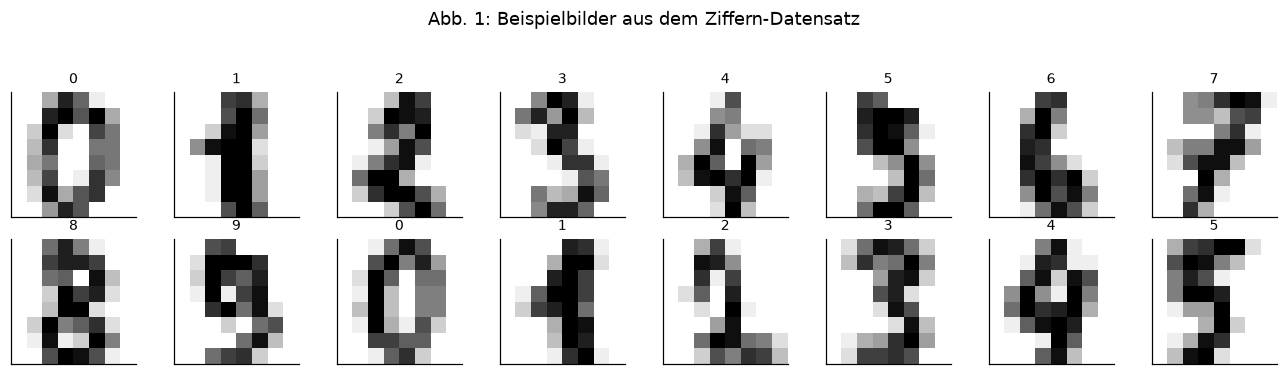

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits = load_digits()
X, y = digits.data, digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"n={len(X)}, p={X.shape[1]} Merkmale (8x8-Bilder), {len(np.unique(y))} Klassen")
print(f"n_train={len(X_train)}, n_test={len(X_test)}")

fig, axes = plt.subplots(2, 8, figsize=(12.0, 3.2))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(8, 8), cmap="gray_r")
    ax.set_title(str(y[i]), fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Abb. 1: Beispielbilder aus dem Ziffern-Datensatz", y=1.05)
plt.tight_layout()
plt.show()

<a id="4"></a>
## 4 Implementierung

In [3]:
@dataclass
class PCA:
    """Hauptkomponentenanalyse via SVD der zentrierten Datenmatrix (Abschnitt 1.3).

    Parameters
    ----------
    n_components : int
        Anzahl der zu behaltenden Hauptkomponenten q.

    Attributes
    ----------
    components_ : ndarray of shape (n_components, n_features)
        Hauptachsen (Zeilen), absteigend nach erklaerter Varianz sortiert.
    mean_ : ndarray of shape (n_features,)
        Merkmalsmittelwerte der Trainingsdaten (fuer Zentrierung/Rekonstruktion).
    explained_variance_ : ndarray of shape (n_components,)
        Varianz entlang jeder Hauptkomponente (Eigenwerte von Sigma).
    explained_variance_ratio_ : ndarray of shape (n_components,)
        Anteil an der Gesamtvarianz je Komponente (Abschnitt 1.4).
    """

    n_components: int
    components_: np.ndarray = field(default=None, init=False)
    mean_: np.ndarray = field(default=None, init=False)
    explained_variance_: np.ndarray = field(default=None, init=False)
    explained_variance_ratio_: np.ndarray = field(default=None, init=False)
    singular_values_: np.ndarray = field(default=None, init=False)

    def fit(self, X: np.ndarray) -> "PCA":
        """Zentriert X und berechnet die Hauptkomponenten via SVD."""
        X = np.asarray(X, dtype=np.float64)
        n = len(X)
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_

        # SVD statt Eigenzerlegung von X^T X -- numerisch stabiler (Notebook 00, Abschn. 2.4)
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)

        all_variance = (S**2) / (n - 1)
        total_variance = all_variance.sum()

        self.components_ = Vt[: self.n_components]
        self.singular_values_ = S[: self.n_components]
        self.explained_variance_ = all_variance[: self.n_components]
        self.explained_variance_ratio_ = self.explained_variance_ / total_variance
        self._all_explained_variance_ratio = all_variance / total_variance  # fuer Scree-Plot
        return self

    def transform(self, X: np.ndarray) -> np.ndarray:
        """Projiziert X auf die q Hauptkomponenten."""
        X_centered = np.asarray(X, dtype=np.float64) - self.mean_
        return X_centered @ self.components_.T

    def inverse_transform(self, Z: np.ndarray) -> np.ndarray:
        """Rekonstruiert Naeherungen der Originaldaten aus der reduzierten Darstellung."""
        return Z @ self.components_ + self.mean_

    def fit_transform(self, X: np.ndarray) -> np.ndarray:
        return self.fit(X).transform(X)

<a id="5"></a>
## 5 Empirische Analyse

### 5.1 Scree-Plot und kumulative erklärte Varianz

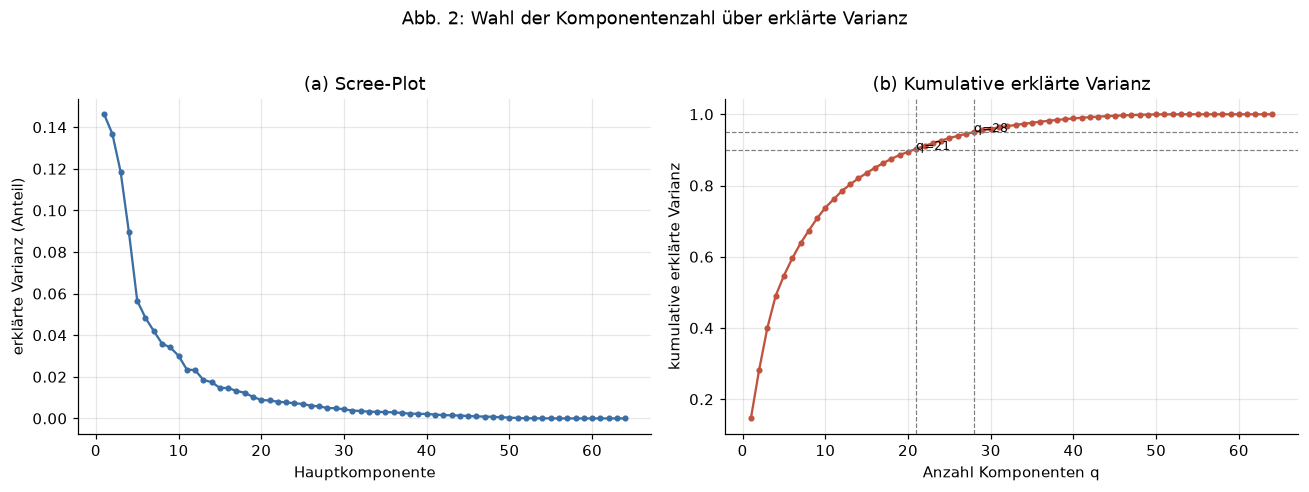

90% der Varianz mit q=21 von 64 Komponenten erklärt (Kompressionsfaktor 3.0x)
95% der Varianz mit q=28 von 64 Komponenten erklärt (Kompressionsfaktor 2.3x)
99% der Varianz mit q=41 von 64 Komponenten erklärt (Kompressionsfaktor 1.6x)


In [4]:
pca_full = PCA(n_components=64).fit(X_train)
cumulative = np.cumsum(pca_full._all_explained_variance_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.3))
axes[0].plot(np.arange(1, 65), pca_full._all_explained_variance_ratio, "o-", ms=3, color="#3b6ea5")
axes[0].set_xlabel("Hauptkomponente")
axes[0].set_ylabel("erklärte Varianz (Anteil)")
axes[0].set_title("(a) Scree-Plot")

axes[1].plot(np.arange(1, 65), cumulative, "o-", ms=3, color="#c1523d")
for threshold in [0.90, 0.95]:
    q_needed = int(np.searchsorted(cumulative, threshold) + 1)
    axes[1].axhline(threshold, color="gray", ls="--", lw=0.8)
    axes[1].axvline(q_needed, color="gray", ls="--", lw=0.8)
    axes[1].annotate(f"q={q_needed}", (q_needed, threshold), fontsize=8)
axes[1].set_xlabel("Anzahl Komponenten q")
axes[1].set_ylabel("kumulative erklärte Varianz")
axes[1].set_title("(b) Kumulative erklärte Varianz")

fig.suptitle("Abb. 2: Wahl der Komponentenzahl über erklärte Varianz", y=1.03)
plt.tight_layout()
plt.show()

for threshold in [0.90, 0.95, 0.99]:
    q = int(np.searchsorted(cumulative, threshold) + 1)
    print(f"{threshold:.0%} der Varianz mit q={q} von 64 Komponenten erklärt "
          f"(Kompressionsfaktor {64/q:.1f}x)")

**Interpretation.** Die einzelnen Eigenwerte fallen rasch ab — bereits die ersten
zehn bis zwanzig Komponenten tragen den Großteil der Gesamtvarianz, da benachbarte
Pixel eines Ziffernbildes stark korreliert sind (starke Redundanz in den
ursprünglichen 64 Merkmalen). Rund $95\,\%$ der Varianz lassen sich mit deutlich
weniger als 64 Komponenten erklären — eine erhebliche Kompression bei geringem
Informationsverlust.

### 5.2 Visualisierung der ersten zwei Hauptkomponenten

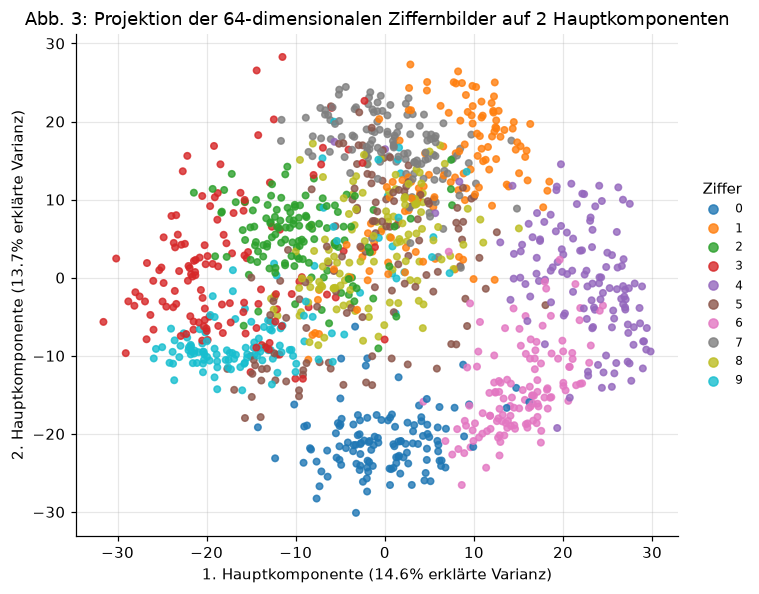

In [5]:
pca_2d = PCA(n_components=2).fit(X_train)
Z_train_2d = pca_2d.transform(X_train)

fig, ax = plt.subplots(figsize=(7.0, 5.5))
scatter = ax.scatter(Z_train_2d[:, 0], Z_train_2d[:, 1], c=y_train, cmap="tab10", s=18, alpha=0.8)
ax.set_xlabel(f"1. Hauptkomponente ({pca_2d.explained_variance_ratio_[0]:.1%} erklärte Varianz)")
ax.set_ylabel(f"2. Hauptkomponente ({pca_2d.explained_variance_ratio_[1]:.1%} erklärte Varianz)")
ax.set_title("Abb. 3: Projektion der 64-dimensionalen Ziffernbilder auf 2 Hauptkomponenten")
legend = ax.legend(*scatter.legend_elements(), title="Ziffer", loc="center left",
                    bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** Obwohl nur rund $\sim\!30\,\%$ der Gesamtvarianz auf zwei
Dimensionen entfallen, bilden sich bereits sichtbare, teils überlappende Cluster
einzelner Ziffern — ein Hinweis darauf, dass die Klassenstruktur zu einem relevanten
Teil mit den Richtungen größter Varianz zusammenfällt, jedoch nicht vollständig
(Übungsaufgabe 3 vertieft diesen Punkt).

### 5.3 Rekonstruktion und Kompressions-Qualitäts-Kompromiss

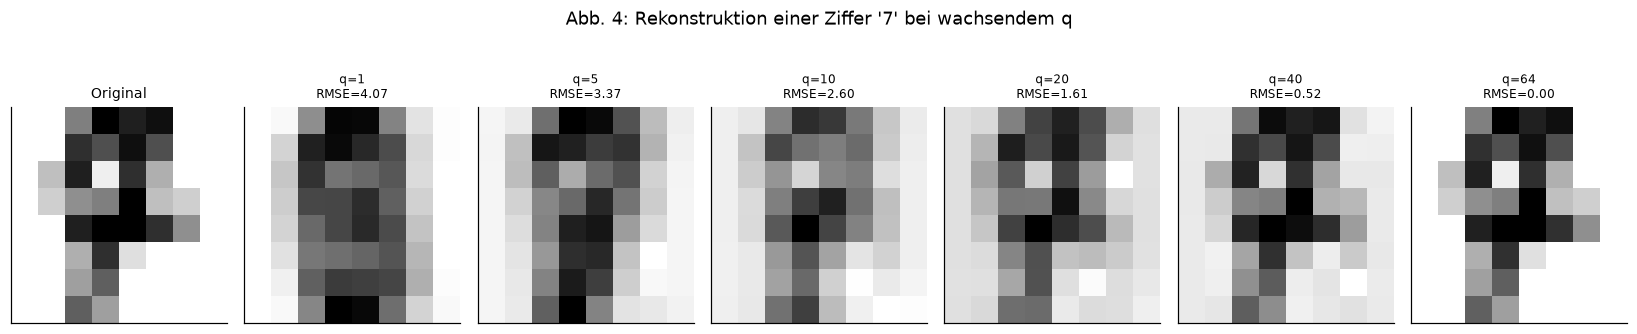

In [6]:
q_values = [1, 5, 10, 20, 40, 64]
example_idx = 7

fig, axes = plt.subplots(1, len(q_values) + 1, figsize=(15.0, 2.6))
axes[0].imshow(X_test[example_idx].reshape(8, 8), cmap="gray_r")
axes[0].set_title("Original", fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

reconstruction_errors = []
for q, ax in zip(q_values, axes[1:]):
    pca_q = PCA(n_components=q).fit(X_train)
    Z = pca_q.transform(X_test[[example_idx]])
    reconstruction = pca_q.inverse_transform(Z)[0]
    error = np.sqrt(np.mean((X_test[example_idx] - reconstruction) ** 2))
    reconstruction_errors.append(error)
    ax.imshow(reconstruction.reshape(8, 8), cmap="gray_r")
    ax.set_title(f"q={q}\nRMSE={error:.2f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"Abb. 4: Rekonstruktion einer Ziffer '{y_test[example_idx]}' bei wachsendem q", y=1.15)
plt.tight_layout()
plt.show()

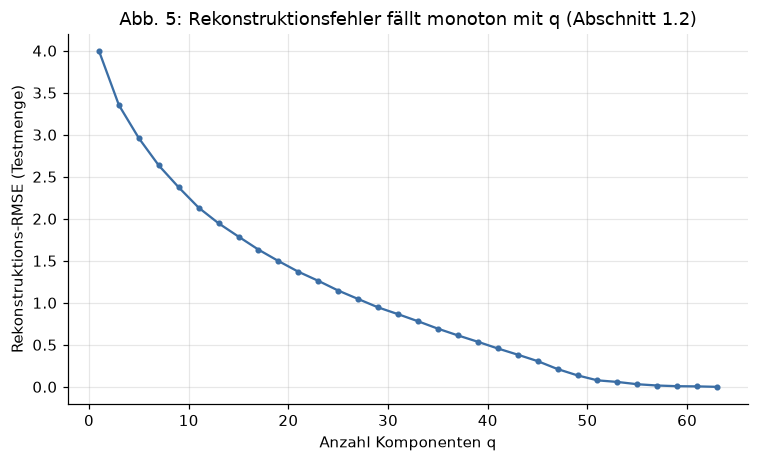

In [7]:
q_grid = np.arange(1, 65, 2)
test_rmse = []
for q in q_grid:
    pca_q = PCA(n_components=int(q)).fit(X_train)
    Z_test = pca_q.transform(X_test)
    reconstruction = pca_q.inverse_transform(Z_test)
    test_rmse.append(np.sqrt(np.mean((X_test - reconstruction) ** 2)))

fig, ax = plt.subplots(figsize=(7.0, 4.3))
ax.plot(q_grid, test_rmse, "o-", ms=3, color="#3b6ea5")
ax.set_xlabel("Anzahl Komponenten q")
ax.set_ylabel("Rekonstruktions-RMSE (Testmenge)")
ax.set_title("Abb. 5: Rekonstruktionsfehler fällt monoton mit q (Abschnitt 1.2)")
plt.tight_layout()
plt.show()

**Interpretation.** Mit wenigen Komponenten ($q=1$–$5$) ist nur die grobe Form
erkennbar; ab $q\approx 10$–$20$ ist die rekonstruierte Ziffer bereits gut lesbar, und
der Rekonstruktionsfehler auf der Testmenge fällt — wie durch die Äquivalenz aus
Abschnitt 1.2 vorhergesagt — streng monoton mit $q$. Wichtig: Die
Hauptkomponenten wurden ausschließlich auf der Trainingsmenge geschätzt und lediglich
auf die Testmenge angewendet (`transform`, nicht `fit`) — dieselbe Trennung von
Schätzung und Anwendung wie bei den überwachten Modellen der Notebooks 01–05.

### 5.4 PCA als Vorverarbeitung: Milderung des Fluchs der Dimensionalität

Notebook 03, Abschnitt 5.3 zeigte, wie irrelevante Rauschdimensionen die Genauigkeit
von k-NN verschlechtern. Hier wird geprüft, ob eine PCA-Vorverarbeitung diesen
Effekt abschwächen kann.

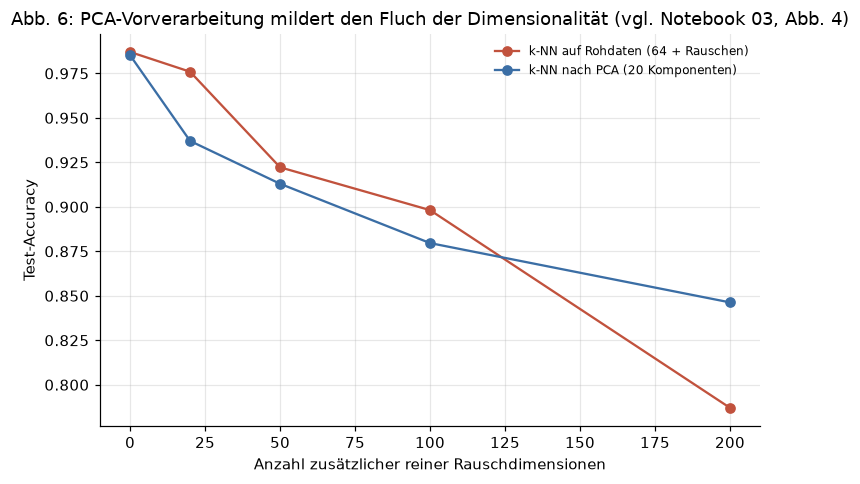

In [8]:
from collections import Counter


class KNearestNeighbors:
    """k-NN-Klassifikator (siehe Notebook 03 fuer die vollstaendige Herleitung)."""

    def __init__(self, k: int = 5) -> None:
        self.k = k

    def fit(self, X, y):
        self.X_train_, self.y_train_ = np.asarray(X, dtype=np.float64), np.asarray(y)
        return self

    def predict(self, X):
        X = np.atleast_2d(np.asarray(X, dtype=np.float64))
        preds = np.empty(len(X), dtype=self.y_train_.dtype)
        for i, x in enumerate(X):
            dist = np.sqrt(np.sum((self.X_train_ - x) ** 2, axis=1))
            idx = np.argpartition(dist, min(self.k, len(dist) - 1))[: self.k]
            preds[i] = Counter(self.y_train_[idx]).most_common(1)[0][0]
        return preds


def accuracy(y_true, y_pred) -> float:
    return float(np.mean(np.asarray(y_true) == np.asarray(y_pred)))


n_noise_dims_grid = [0, 20, 50, 100, 200]
acc_raw, acc_pca = [], []

for n_noise in n_noise_dims_grid:
    gen = np.random.default_rng(RANDOM_STATE)
    noise_train = gen.normal(scale=X_train.std(), size=(len(X_train), n_noise))
    noise_test = gen.normal(scale=X_train.std(), size=(len(X_test), n_noise))
    X_train_aug = np.hstack([X_train, noise_train])
    X_test_aug = np.hstack([X_test, noise_test])

    knn_raw = KNearestNeighbors(k=5).fit(X_train_aug, y_train)
    acc_raw.append(accuracy(y_test, knn_raw.predict(X_test_aug)))

    pca_prep = PCA(n_components=20).fit(X_train_aug)
    Z_train_aug = pca_prep.transform(X_train_aug)
    Z_test_aug = pca_prep.transform(X_test_aug)
    knn_pca = KNearestNeighbors(k=5).fit(Z_train_aug, y_train)
    acc_pca.append(accuracy(y_test, knn_pca.predict(Z_test_aug)))

fig, ax = plt.subplots(figsize=(7.0, 4.5))
ax.plot(n_noise_dims_grid, acc_raw, "o-", color="#c1523d", label="k-NN auf Rohdaten (64 + Rauschen)")
ax.plot(n_noise_dims_grid, acc_pca, "o-", color="#3b6ea5", label="k-NN nach PCA (20 Komponenten)")
ax.set_xlabel("Anzahl zusätzlicher reiner Rauschdimensionen")
ax.set_ylabel("Test-Accuracy")
ax.set_title("Abb. 6: PCA-Vorverarbeitung mildert den Fluch der Dimensionalität (vgl. Notebook 03, Abb. 4)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation.** Ohne PCA fällt die k-NN-Genauigkeit mit wachsender Anzahl
Rauschdimensionen, exakt wie in Notebook 03 beobachtet — die euklidische Distanz wird
zunehmend von irrelevanten Dimensionen dominiert. Mit vorgeschalteter PCA auf 20
Komponenten bleibt die Genauigkeit deutlich stabiler: Da die informativen 64
Bildmerkmale stark korreliert sind, konzentriert sich ihre gemeinsame Varianz auf
wenige Hauptkomponenten, während unkorreliertes Rauschen sich gleichmäßig auf alle 64+
Original-Dimensionen verteilt und daher in den ersten Hauptkomponenten unterrepräsentiert
ist. PCA wirkt hier faktisch als Rauschfilter — ein Nebeneffekt der
Varianzmaximierung, keine explizite Zielsetzung.

### 5.5 Validierung gegen `scikit-learn`

In [9]:
from sklearn.decomposition import PCA as SKPCA

own = PCA(n_components=10).fit(X_train)
reference = SKPCA(n_components=10, random_state=RANDOM_STATE).fit(X_train)

print("Erklärte Varianzquote (erste 5 Komponenten):")
print(f"  Eigenimplementierung: {own.explained_variance_ratio_[:5]}")
print(f"  scikit-learn:         {reference.explained_variance_ratio_[:5]}")

# Hauptachsen sind nur bis auf das Vorzeichen eindeutig -- Betrag vergleichen.
max_abs_diff = np.abs(np.abs(own.components_) - np.abs(reference.components_)).max()
print(f"\nmax. |Differenz| der Hauptachsen (nach Vorzeichenangleich): {max_abs_diff:.2e}")

Erklärte Varianzquote (erste 5 Komponenten):
  Eigenimplementierung: [0.14620299 0.1367047  0.11839276 0.08939532 0.05657009]
  scikit-learn:         [0.14620299 0.1367047  0.11839276 0.08939532 0.05657009]

max. |Differenz| der Hauptachsen (nach Vorzeichenangleich): 1.64e-14


**Interpretation.** Erklärte Varianzanteile stimmen exakt überein; die Hauptachsen
selbst sind nur bis auf das Vorzeichen eindeutig bestimmt (ist $\mathbf{v}$ ein
Eigenvektor, ist es auch $-\mathbf{v}$), weshalb der Vergleich auf Beträgen erfolgt.

<a id="6"></a>
## 6 Diskussion und Grenzen

**Ergebnis.** PCA komprimiert die 64-dimensionalen Ziffernbilder mit vergleichsweise
wenigen Komponenten nahezu verlustfrei, liefert eine informative 2D-Visualisierung der
Klassenstruktur und mildert nachweislich den Fluch der Dimensionalität für einen
nachgeschalteten k-NN-Klassifikator.

**Methodische Einschränkungen.**

1. *Nur lineare Struktur.* PCA findet lineare Unterräume; nicht-lineare
   Mannigfaltigkeiten (z.\,B. eine gekrümmte "Swiss Roll"-Struktur) werden nicht
   korrekt erfasst. Kernel-PCA oder Autoencoder-basierte Verfahren adressieren dies.
2. *Skalensensitivität.* Ohne Standardisierung dominieren Merkmale mit großer
   Varianz (z.\,B. Pixel in Bildmitte vs. Rand) die ersten Komponenten allein aufgrund
   ihrer Skala, nicht ihrer inhaltlichen Bedeutung.
3. *Varianz $\neq$ Relevanz für die Zielgröße.* PCA ist unüberwacht: Eine Richtung mit
   hoher Varianz kann für eine Klassifikationsaufgabe irrelevant sein, während eine
   Richtung mit geringer Varianz die Klassen perfekt trennt. Lineare
   Diskriminanzanalyse (LDA) optimiert stattdessen explizit für Klassentrennung.
4. *Interpretierbarkeit der Komponenten.* Hauptkomponenten sind Linearkombinationen
   aller Originalmerkmale und daher oft schwerer inhaltlich zu deuten als die
   Originalmerkmale selbst.

**Anschluss.** Notebook 08 schließt die Reihe mit einem neuronalen Netz ab, das
nicht-lineare Merkmalstransformationen direkt im Modell selbst lernt — eine
Verallgemeinerung des hier linearen PCA-Ansatzes.

<a id="7"></a>
## 7 Übungsaufgaben

1. **Standardisierung vs. Zentrierung.** Wiederholen Sie Abschnitt 5.1 mit
   standardisierten (nicht nur zentrierten) Merkmalen. Verändert sich die Anzahl der
   für $95\,\%$ Varianz benötigten Komponenten?
2. **Whitening.** Erweitern Sie die `PCA`-Klasse um eine `whiten`-Option, die die
   transformierten Komponenten zusätzlich durch $\sqrt{\lambda_j}$ teilt, sodass sie
   Einheitsvarianz haben. Wozu könnte das nützlich sein?
3. **Varianz vs. Klassentrennung.** Konstruieren Sie einen 2D-Datensatz, bei dem die
   Richtung maximaler Varianz orthogonal zur optimalen Klassentrennlinie steht (z.\,B.
   zwei längliche, parallel versetzte Klassenwolken). Zeigen Sie, dass die erste
   Hauptkomponente hier für Klassifikation ungeeignet ist.
4. **Eigengesichter-Analogie.** Visualisieren Sie die ersten 10 Hauptachsen
   (`components_`) als $8\times 8$-Bilder. Was repräsentieren diese "Eigenziffern"
   anschaulich?
5. **Kernel-PCA.** Wenden Sie `sklearn.decomposition.KernelPCA` mit RBF-Kernel auf die
   Halbmond-Daten aus Notebook 03/06 an und vergleichen Sie die 2D-Projektion mit der
   linearen PCA.

<a id="8"></a>
## 8 Literatur

* Pearson, K. (1901). On lines and planes of closest fit to systems of points in
  space. *Philosophical Magazine*, 2(11), 559–572.
* Hotelling, H. (1933). Analysis of a complex of statistical variables into principal
  components. *Journal of Educational Psychology*, 24(6), 417–441.
* Bishop, C. M. (2006). *Pattern Recognition and Machine Learning*. Springer. Kap. 12.
* Jolliffe, I. T. (2002). *Principal Component Analysis* (2. Aufl.). Springer.